# Mutual Information for Stereo-Derived Topography (of Venus) (MISDT)

Author: Kas Knicely; jknicely@alaska.edu

Affiliation: University of Alaska Fairbanks

## Description
This is a pilot code version to extract stereo-derived topography from Venus left/right image pairs using Mutual Information (MI). This will be used on both left/left and left/right pairs to allow comparison between already extant stereo-derived topography (see Herrick et al. [2012]). 

### Briefly about MI
MI is a probabilistic method by which to map the likelihood of a pixel value in one image corresponding to a pixel value in another. This is important as it may allow for matches in opposite look radar imagery, a feat that standard cross-correlation techniques cannot achieve. 

## To Do
* Create structure of notebook
* <s>Get data for testing</s>
* Figure out python modules
* Testing
  * Get image overlay to work. 
* Write hierarchical search code
  * write rough draft script.
  * convert rough draft script to a function. 
  * give the windowSearchSize an optional step size argument. Allow people to move the clip more than just one pixel. This will be useful for large images. 

## Installed Packages

This is a list of all of the packages I have installed. This should not be needed since packaging code can figure out which dependencies I have. 

[NONE]

***
## Load modules

In [6]:
import numpy as np
import sklearn as skl # this contains the code to calculate mutual information; sklearn.metrics.mutual_info_score()
from sklearn.metrics import mutual_info_score
from sklearn.metrics import normalized_mutual_info_score 
import scipy # for image processing filters. 

# for image loading
import rasterio
import rioxarray as rxr

# general utility
import os
from pathlib import Path
import matplotlib.pyplot as plt
import time # for timing code runs

## Test of Mutual Information

In [8]:
labels_true = [0, 1, 1, 0, 1, 0]
labels_pred = [0, 1, 0, 0, 1, 1]
MI = mutual_info_score(labels_true, labels_pred)
MI_reverse = mutual_info_score(labels_pred, labels_true)

print(f'scores:\nMI = {MI}\nMI_reverse = {MI_reverse}\nMI == MI_reverse = {MI==MI_reverse}')

scores:
MI = 0.0566330122651324
MI_reverse = 0.0566330122651324
MI == MI_reverse = True


***
## Set up important functions

NOTE: much of this can probably be stripped from MATLAB code I've already written. 

* parallax equation
* hierarchical looper
    * This needs to allow selection between different types of 

In [8]:
# PUT FUNCTIONS HERE!!!!

***
## Get your data

This code assumes your image set from which topography will be created are in the same folder. 

In [11]:
def load_image(flnm):
    # function to load image as an xarry
    
    src = rxr.open_rasterio(flnm).squeeze(dim='band')
    src = src.drop_vars(['band'])
    return src

### Select folder from which to load imagery

In [14]:
folder_data = Path(os.getcwd(),'testData')

### Select files and check that they exist

In [17]:
# leftlook file name
ll = 'VenusMagellanLeftLook_MAP2_SINU.tif'
# rightlook file name
rl = 'VenusMagellanRightLook_MAP2_SINU.tif'
# stereolook file name
sl = 'VenusMagellanStereoLook_MAP2_SINU.tif'

# create full path name for each
flnm_ll = Path(folder_data, ll)
flnm_rl = Path(folder_data, rl)
flnm_sl = Path(folder_data, sl)
flnms = [flnm_ll, flnm_rl, flnm_sl]

# check if files exist
for flnm in flnms:
    if os.path.exists(flnm):
        print(f"File Found: {flnm}")
    else:
        print(f"\tWARNING!!!\n\tWARNING!!!\nNOT FOUND:  {flnm}")

File Found: C:\Users\jknicely\Documents\Science\ASF Post Doc\MISDT\MISDT\testData\VenusMagellanLeftLook_MAP2_SINU.tif
File Found: C:\Users\jknicely\Documents\Science\ASF Post Doc\MISDT\MISDT\testData\VenusMagellanRightLook_MAP2_SINU.tif
File Found: C:\Users\jknicely\Documents\Science\ASF Post Doc\MISDT\MISDT\testData\VenusMagellanStereoLook_MAP2_SINU.tif


### Load image data

In [19]:
leftlook = load_image(flnm_ll)
rightlook = load_image(flnm_rl)
stereolook = load_image(flnm_sl)

In [21]:
leftlook

<xarray.DataArray (y: 1690, x: 2750)> Size: 5MB
array([[  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       ...,
       [ 90,  94,  87, ...,  79,  72,  93],
       [ 83,  80,  79, ...,  95,  98, 117],
       [ 92,  85,  84, ..., 116, 118, 126]], dtype=uint8)
Coordinates:
  * x            (x) float64 22kB -1.031e+05 -1.03e+05 ... 1.03e+05 1.031e+05
  * y            (y) float64 14kB 1.447e+06 1.447e+06 ... 1.32e+06 1.32e+06
    spatial_ref  int32 4B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     0
    scale_factor:   1.0
    add_offset:     0.0

### Store images in a single dictionary

In [53]:
myImages = {}
myImages['leftlook'] = leftlook.copy(deep=True)
myImages['rightlook'] = rightlook.copy(deep=True)
myImages['stereolook'] = stereolook.copy(deep=True)

myImages

{'leftlook': <xarray.DataArray (y: 1690, x: 2750)> Size: 5MB
 array([[  1,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [ 90,  94,  87, ...,  79,  72,  93],
        [ 83,  80,  79, ...,  95,  98, 117],
        [ 92,  85,  84, ..., 116, 118, 126]], dtype=uint8)
 Coordinates:
   * x            (x) float64 22kB -1.031e+05 -1.03e+05 ... 1.03e+05 1.031e+05
   * y            (y) float64 14kB 1.447e+06 1.447e+06 ... 1.32e+06 1.32e+06
     spatial_ref  int32 4B 0
 Attributes:
     AREA_OR_POINT:  Area
     _FillValue:     0
     scale_factor:   1.0
     add_offset:     0.0,
 'rightlook': <xarray.DataArray (y: 1690, x: 2750)> Size: 5MB
 array([[  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        [  0,   0,   0, ...,   0,   0,   0],
        ...,
        [108, 111, 113, ..., 115, 116, 109],
        [ 96, 103, 108, ..., 116, 109, 100],
        [ 90,  89,  85, ..., 1

***
### Check image location data

Are the loaded images the same size?  
Do the loaded images have the same geographic (lat/lon) location?

In [27]:
# import rasterio

def pixel_to_latlon(image_path, row, col):
    with rasterio.open(image_path) as src:
        # Convert pixel coordinates to geographic coordinates
        # lon, lat = src.xy(row, col)
        # Getting actual lon and lat are much more complicated! I have to convert to angles and other shit. Or download a Venus reference ellipsoid. 
        return lat, lon

# Example usage:
# lat, lon = pixel_to_latlon("your_geotiff.tif", 100, 200) # row 100, column 200
# print(f"Latitude: {lat}, Longitude: {lon}")

In [29]:
lat1, lon1 = pixel_to_latlon(flnm_ll, 0, 0)
lat1, lon1

NameError: name 'lat' is not defined

In [46]:
myImages['leftlook'].spatial_ref

<xarray.DataArray 'spatial_ref' ()> Size: 4B
array(0)
Coordinates:
    spatial_ref  int32 4B 0
Attributes: (12/16)
    crs_wkt:                         PROJCS["Sinusoidal Venus",GEOGCS["GCS_Ve...
    semi_major_axis:                 6051000.0
    semi_minor_axis:                 6051000.0
    inverse_flattening:              0.0
    reference_ellipsoid_name:        Venus
    longitude_of_prime_meridian:     0.0
    ...                              ...
    grid_mapping_name:               sinusoidal
    longitude_of_projection_origin:  78.0
    false_easting:                   0.0
    false_northing:                  0.0
    spatial_ref:                     PROJCS["Sinusoidal Venus",GEOGCS["GCS_Ve...
    GeoTransform:                    -103125.0 75.0 0.0 1446900.0 0.0 -75.0

In [79]:
# X_geo = GT(0) + X_pixel * GT(1) + Y_line * GT(2)
# Y_geo = GT(3) + X_pixel * GT(4) + Y_line * GT(5)
X_pixel = leftlook.x.values[0]
Y_line = leftlook.y.values[0]
X_geo = -103125.0 + X_pixel*75.0 + Y_line*0.0
Y_geo = 1446900.0 + X_pixel*0.0  + Y_line*-75.0

In [81]:
X_geo, Y_geo

(-7834687.5, -107067787.5)

In [95]:
raster = rasterio.open(flnm_ll)

# get important GIS info
CRS = raster.crs
transform = raster.transform
CRS, transform

(CRS.from_wkt('PROJCS["Sinusoidal Venus",GEOGCS["GCS_Venus",DATUM["D_Venus",SPHEROID["Venus",6051000,0]],PRIMEM["Reference_Meridian",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",78],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'),
 Affine(75.0, 0.0, -103125.0,
        0.0, -75.0, 1446900.0))

In [99]:
CRS

CRS.from_wkt('PROJCS["Sinusoidal Venus",GEOGCS["GCS_Venus",DATUM["D_Venus",SPHEROID["Venus",6051000,0]],PRIMEM["Reference_Meridian",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Sinusoidal"],PARAMETER["longitude_of_center",78],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]')

In [107]:
type(raster.crs)

rasterio.crs.CRS

***
Show images

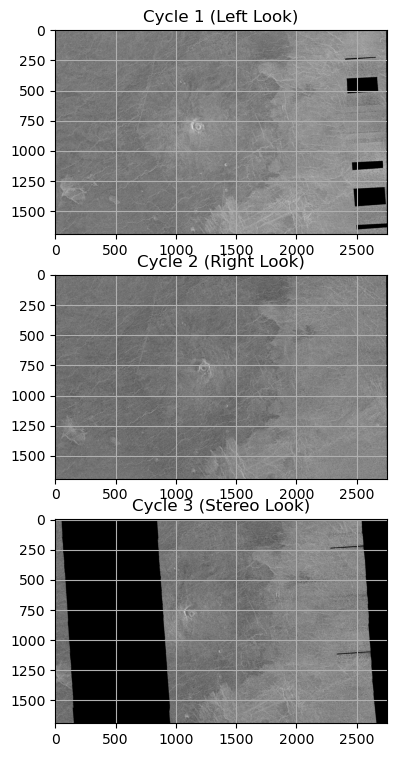

In [31]:
fig_first = plt.figure(figsize=(12,9))
ax_ll = plt.subplot(3,1,1)
ax_rl = plt.subplot(3,1,2)
ax_sl = plt.subplot(3,1,3)
# show imagery
ax_ll.imshow(leftlook, cmap='gray', interpolation=None)
ax_rl.imshow(rightlook, cmap='gray', interpolation=None)
ax_sl.imshow(stereolook, cmap='gray', interpolation=None)
# add titles
ax_ll.title.set_text('Cycle 1 (Left Look)')
ax_rl.title.set_text('Cycle 2 (Right Look)')
ax_sl.title.set_text('Cycle 3 (Stereo Look)')
# add grid lines
ax_ll.grid()
ax_rl.grid()
ax_sl.grid()
# make plot show
plt.show()

## Pre-process Imagery (OPTIONAL)

Median filtering and binning of values may be necessary to stabilize the MI. 

Median filtering just cleans the data up a bit (I'll probably go with a 3x3; just to make the values a tiny more stable). This will likely be a standard step. For this

Binning of values is a hypothetically required step. The input radar images have values ranging from 0 to 255, a total of 256 values. Mapping 256 values in one image to 256 values in another image may be too difficult; it might require too much computational power, or it may simply create so many tiny bins that a consistent relationship between radar images cannot be made. 

***
<b>Median Filter</b>

In this step, the image data undergoes a median filtering. This reduces speckle and data noise. 

For this step, the kernel_size must be an odd integer of 3 or larger. 

In [71]:
kernel_size = 3

In [ ]:
leftlook = scipy.signal.medfilt2d(leftlook, kernel_size = kernel_size)
rightlook = scipy.signal.medfilt2d(rightlook, kernel_size = kernel_size)
stereolook = scipy.signal.medfilt2d(stereolook, kernel_size = kernel_size)

In [73]:
for key in myImages:
    myImages[key].values = scipy.signal.medfilt2d(myImages[key].values, kernel_size=kernel_size)

***
<b>Binning</b>

In this step, the digital values are re-binned into a smaller subset. This is done to reduce the dimensionality with which the MI calculation must deal. IT IS UNCLEAR IF THIS WILL HELP AND IS PURELY THEORETICAL!!!

Bin types:
* equalCount
  * Each bin has an (approximately) equal number of pixels in each bin.
  * The range of each bin is different! 
* equalSize
  * Each bin is the same size. 
  * The range of each bin is the same!

In [75]:
# select number of bins
num_bins = 8

In [ ]:
# select method of binning
# In other words, how will the old values be rewritten? 
# initially, this just breaks them up into bins of equal size
binType = 'equalSize'

In [ ]:
# rebin the values
if binType == 'equalCount':
    for key in myImages:
        unique_vals, unique_counts = np.unique(myImages[key].values, counts=True)
        flattened

if binType == 'equalSize':
    for key in myImages: 

***
# Run Hierarchical MI on image pairs

### Development Code

General Steps of Code
* Get MI map of clip applied to an image.
* Get location of clip in image. (i.e., convert MI map to a location).
* Go to next clip size/hierarchy. 

TODO
* norm/MImap_clip2image
  * Speed it up! 
    * May need to move .values.ravel() outside of loop.
  * Make it search a finite area rather than the whole image...NO!!! Have that in other code! The 'image' passed to 'MImap...' won't be the entire image, just the area that the user designates to search!

NOTE
* MImap_clip2image/normMImap_clip2image are both the most basic, foundational part of this code. These will be run inside a function that calls it repeatedly to produce an MI map for each hierarchical size. 

In [80]:
def MImap_clip2image(clip,image):
    """
    Function to get MI map of a clip compared to an image. 
    This will 

    Input:
        clip: a clip or subset of an image that is compared to 'image'. This is a 2D array. 
        image: an image to which 'clip' is compared. This is a 2D array

    Output: 
        MImap: a 2D array of mutual information values. It will be the size of 'image' minus the size of 'clip'. 

    Notes:
        A good test is to run this code using a clip of an image against the same image; in other words, 'clip' comes from 'image'. 
        This should give a very high MI value at a single point and very low values everywhere else. 
    """
    # Get some important initial info (size of the clip and extents of image to search)
    xSize, ySize = clip.shape
    xSearch = image.shape[1]-xSize-1
    ySearch = image.shape[0]-ySize-1

    # Initialize 'MImap' to all zeros at the size of the area to search. 
    MImap = np.zeros([ySearch, xSearch], dtype=float)
    
    # loop through 'image' to calculate MI for all possible clips of 'image'. 
    for i in range(0,xSearch):
        for j in range(0,ySearch):
            otherClip = image[i:i+xSize, j:j+ySize]
            MImap[j][i] = mutual_info_score(clip.values.ravel(), otherClip.values.ravel())
    
    return MImap

In [82]:
def normMImap_clip2image(clip,image):
    """
    Function to get normalized MI map of a clip compared to an image. 
    This will 

    Input:
        clip: a clip or subset of an image that is compared to 'image'. This is a 2D array. 
        image: an image to which 'clip' is compared. This is a 2D array

    Output: 
        MImap: a 2D array of mutual information values. It will be the size of 'image' minus the size of 'clip'. 

    Notes:
        A good test is to run this code using a clip of an image against the same image; in other words, 'clip' comes from 'image'. 
        This should give a very high MI value at a single point and very low values everywhere else. 
    """
    # Get some important initial info (size of the clip and extents of image to search)
    xSize, ySize = clip.shape
    xSearch = image.shape[1]-xSize-1
    ySearch = image.shape[0]-ySize-1

    # Initialize 'MImap' to all zeros at the size of the area to search. 
    normMImap = np.zeros([ySearch, xSearch], dtype=float)
    
    # loop through 'image' to calculate MI for all possible clips of 'image'. 
    for i in range(0,xSearch):
        for j in range(0,ySearch):
            otherClip = image[i:i+xSize, j:j+ySize]
            normMImap[j][i] = normalized_mutual_info_score(clip.values.ravel(), otherClip.values.ravel())
    
    return normMImap

In [84]:
# creating test clip and image. 
testImage = myImages['leftlook'][0:100, 0:100]
# testImage = testImage[0:100, 0:100]
testClip = testImage[0:51, 0:51]

In [86]:
# calculating MI and norm MI maps

testMI = MImap_clip2image(testClip, testImage)
testNormMI = normMImap_clip2image(testClip, testImage)

In [172]:
# convert MI_map to the location of the clip in the image

# find location of max of MI_map
flattened_index = np.argmax(testMI)
rowMax1, colMax1 = np.unravel_index(flattened_index, testMI.shape)

0

In [ ]:
windowSearch = [21,11]

# take a sub-clip of clip and find it's best location in some window (kind of like doing the windowSearchSize)
testClipClip = testClip[11:21, 11:21]
testImageImage = testImage[rowMax1-windowSearch[0]:rowMax1+windowSearch[0], colMax1-windowSearch[1]:colMax1+windowSearch[1]]

for i in range(0,testImageImage.shape[0]):
    for j in range(0,testImageImage.shape[1]):
        # get MI map

# get max MI location for level 2

# combine max MI locations level 1 and level 2


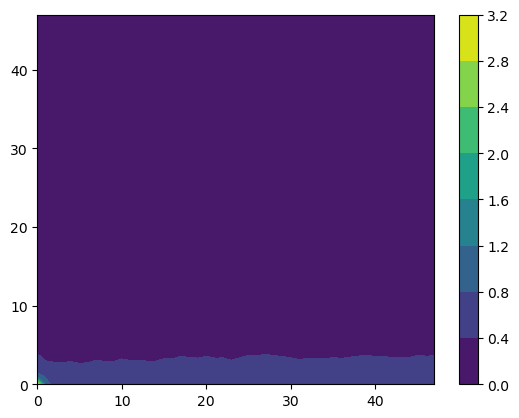

In [106]:
xMax, yMax = testMI.shape
x = np.arange(0,xMax)
y = np.arange(0,yMax)

myIM = plt.contourf(x, y, testMI, cmap='viridis') #, vmin=np.min(testMI), vmax=np.max(testMI))
cbar = plt.colorbar(myIM)

plt.show()

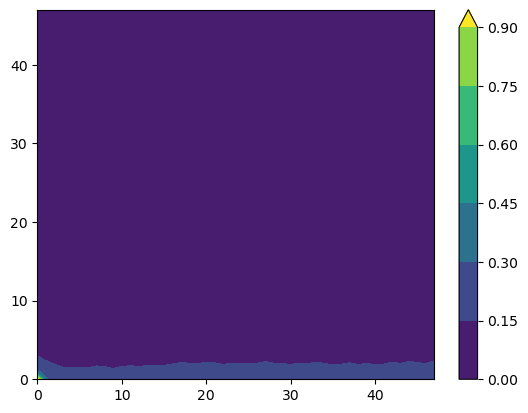

In [124]:
xMax, yMax = testNormMI.shape
x = np.arange(0,xMax)
y = np.arange(0,yMax)

myIM = plt.contourf(x, y, testNormMI, cmap='viridis', vmin=0, vmax=1, extend='max')
plt.colorbar(myIM)

plt.show()

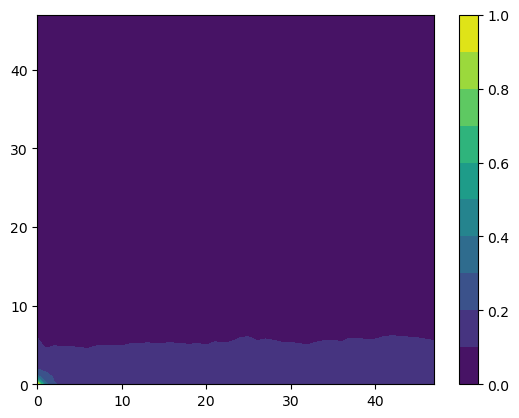

In [132]:
xMax, yMax = testNormMI.shape
x = np.arange(0,xMax)
y = np.arange(0,yMax)

myIM = plt.contourf(x, y, testNormMI, cmap='viridis', vmin=0, vmax=1, levels=np.linspace(0,1,11))
plt.colorbar(myIM)

plt.show()



### Create function that plots original image, original clip, and the clip put on the image based on MI score. 

Text(0.5, 1.0, 'Clip overlay\nTHIS IS WRONG!!!')

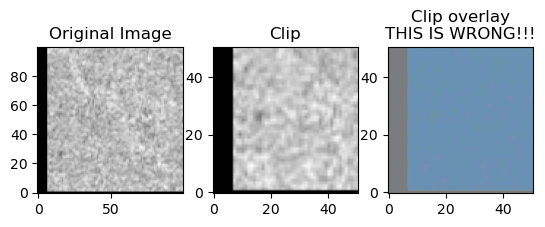

In [360]:
figgy, axs = plt.subplots(1,3)

imagy_original = axs[0].imshow(testImage, cmap='gray', origin='lower')
axs[0].set_title('Original Image')
clipy_original = axs[1].imshow(testClip, cmap='gray', origin='lower')
axs[1].set_title('Clip')
testImage_copy = testImage.copy(deep=True)
myY, myX = testClip.shape
testImage_copy.values[0:myX,0:myY] = testClip
imagy_matched = axs[2].imshow(testImage, cmap='gray', origin='lower')
# axs[2].imshow(testClip, cmap='Blues', origin='lower', alpha=0.5, extent=[0,myX,0,myY])
axs[2].imshow(testClip, cmap='Blues', origin='lower', alpha=0.5)
axs[2].set_title('Clip overlay\nTHIS IS WRONG!!!')


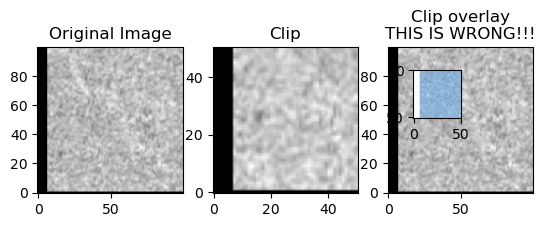

In [370]:
figgy, axs = plt.subplots(1,3)

imagy_original = axs[0].imshow(testImage, cmap='gray', origin='lower')
axs[0].set_title('Original Image')
clipy_original = axs[1].imshow(testClip, cmap='gray', origin='lower')
axs[1].set_title('Clip')
testImage_copy = testImage.copy(deep=True)
myX, myY = testClip.shape
testImage_copy.values[0:myX,0:myY] = testClip
imagy_matched = axs[2].imshow(testImage, cmap='gray', origin='lower')
# axs[2].imshow(testClip, cmap='Blues', origin='lower', alpha=0.5, extent=[0,myX,0,myY])
axs[2].set_title('Clip overlay\nTHIS IS WRONG!!!')
ax_inset = figgy.add_axes([0.7, 0.5, 0.1, 0.1])
ax_inset.imshow(testClip, cmap='Blues', alpha=0.5)

### Testing hierarchical search code

In [136]:
x1,y1 = 101, 31
x2,y2 = 31, 11

# set size of window search (how far the code will move the clip across the image while searching for a match)
"""
The clip will be moved both in the positive and negative direction. E.g., if the windowSearchSize[0][0] is 10, 
then the clip will be moved from -10 pixels to +10 pixels in the x direction from its corresponding location in 
the second image. 
"""
windowSearchSize = [
    [x1, y1],
    [x2, y2]
]
# set the size of each clip hierarchy
clipSize = [
    [x1, y1],
    [x2, y2]
]

In [167]:
if len(clipSize) is not len(windowSearchSize):
    raise CustomError("clipSize and windowSearchSize do not have the same number of entries!")
else: 
    print("Starting MI mapping...")
    start_time = time.time()

    # initialize container for MI maps. 
    # NOTE: MI map for each windowSearchSize will have a different size. 


    
    
    # loop through each clipSize and calculate the MI map. 
    for i in range(0,len(clipSize)):
        # loop through each location in Image to search
        # create clip
        myClip = myImage['leftlook']
        if i == 0:
            # stuff
        elif i >= 1:
            # stuff; have to do this because the later MI_maps will need to be 

    
    end_time = time.time()
    run_time = end_time - start_time
    print(f"Run time: {run_time/60.0:.2f} minutes")


Starting MI mapping...
Run time: 0.33 minutes


## END GOAL BELOW (above is working code)

In [ ]:
### --- Define parallax equation function --- ###
# Move to 'Set up important functions' section once complete and trouble-shooted. 
def parallax():

    return

### --- Define hierarchical looper function --- ###
# Move to 'Set up important functions' section once complete and trouble-shooted. 
def looper(imageA, imageB, Settings):

    return MI_score, DEM


In [54]:
mySettings = {
    'windowSizes': [11, 33, 99],
    'xSearch': 101,
    'ySearch': 11
}

mySettings

{'windowSizes': [11, 33, 99], 'xSearch': 101, 'ySearch': 11}

In [56]:
mySettings['windowSizes'][0]

11

***
## Qualify the fidelity of the resultant DEMs

### Compare the resultant DEMS to each other and previously existing DEMs

Compare my resultant DEMs (the left/left & the two left/right) to:
* GTDR
* Robbie's stereo-derived DEMs
* Each other
    * C1/C2 to
        * C2/C3
        * C1/C3
    * C2/C3 to
        * C1/C3
     
NOTE: This may need to be done in something like ArcGIS or QGIS. 

### Geometrically Terrain Correct (GTC) the SAR imagery using the resultant DEMS

### Compare GTC images to each other

NOTE: This may need to be done manually. 

***
## Export the stereo-DEMs

In [ ]:
### --- Define function to export stereo-DEMs with appropriate geolocation --- ###
# Move to 'Set up important functions' section once complete and trouble-shooted. 
def DEMs2geotiffs():

    return